# Visualize GHD VAE / VQ-VAE Generation

Set `MODEL_KIND` to `"vae"` or `"vqvae"`, choose a checkpoint, then run the notebook. For VAE this samples `z ~ N(0, I)`. For VQ-VAE, random generation samples codebook indices uniformly because no autoregressive/prior model over code indices is trained yet; `MODE = "reconstruct"` is usually the more reliable VQ-VAE sanity view.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
if ROOT.name == "v2":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dataset.ghd_datasets import ProcessedGHDDataset
from dataset.preprocess import get_ghd_reconstruct
from v2.vae_models import TypeConditionalVAE
from v2.vqvae_models import ConditionalGHDVQVAE

DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
PROCESSED_ROOT = ROOT / "dataset" / "processed"
print(ROOT, DEVICE)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Unable to load the following plugins:

	libfilter_embree.so: libfilter_embree.so does not seem to be a Qt Plugin.

Cannot load library /home/yaplab2/miniconda3/envs/new/lib/python3.11/site-packages/pymeshlab/lib/plugins/libfilter_embree.so: (/home/yaplab2/miniconda3/envs/new/lib/python3.11/site-packages/pymeshlab/lib/plugins/../libembree4.so.4: undefined symbol: _ZN3tbb10interface78internal20isolate_within_arenaERNS1_13delegate_baseEl)

/media/yaplab2/HDD Storage/wenhao/AneuG cuda:1


In [2]:
MODEL_KIND = "vae"  # "vae" or "vqvae"
MODE = "random"       # "random" or "reconstruct"
ANEURYSM_TYPE = 1      # 0=bifurcated, 1/2=sidewall
NUM_SAMPLES = 6

# Leave as None to use the latest epoch_*.pth in the default checkpoint directory.
CKPT_PATH = None

def latest_checkpoint(model_kind):
    ckpt_dir = ROOT / "checkpoints" / "v2" / ("ghd_vqvae" if model_kind == "vqvae" else "ghd_vae")
    paths = sorted(ckpt_dir.glob("epoch_*.pth"))
    if not paths:
        raise FileNotFoundError(f"No epoch_*.pth checkpoints found in {ckpt_dir}")
    return paths[-1]

ckpt_path = Path(CKPT_PATH) if CKPT_PATH is not None else latest_checkpoint(MODEL_KIND)
checkpoint = torch.load(ckpt_path, map_location=DEVICE)
print(ckpt_path)
print("epoch", checkpoint.get("epoch"))

/media/yaplab2/HDD Storage/wenhao/AneuG/checkpoints/v2/ghd_vae/epoch_10000.pth
epoch 10000


In [3]:
def build_model(model_kind, checkpoint):
    state = checkpoint["model"]
    withscale = bool(checkpoint.get("withscale", True))
    if model_kind == "vae":
        input_total = state["fc1.weight"].shape[1]
        input_dim = input_total - 1 if withscale else input_total
        hidden_dim = state["fc1.weight"].shape[0]
        latent_dim = state["fc21.weight"].shape[0]
        num_types, condition_dim = state["type_embedding.weight"].shape
        model = TypeConditionalVAE(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            withscale=withscale,
            num_types=num_types,
            condition_dim=condition_dim,
        )
    elif model_kind == "vqvae":
        model = ConditionalGHDVQVAE(
            seq_len=int(checkpoint.get("seq_len", 144)),
            channels=int(checkpoint.get("channels", 3)),
            num_types=int(checkpoint.get("num_types", 3)),
            hidden_dim=int(checkpoint.get("hidden_dim", 128)),
            embedding_dim=int(checkpoint.get("embedding_dim", 64)),
            num_codes=int(checkpoint.get("num_codes", 128)),
        )
    else:
        raise ValueError(model_kind)
    model.load_state_dict(state)
    model.to(DEVICE).eval()
    return model

model = build_model(MODEL_KIND, checkpoint)
mean = checkpoint["mean"].to(DEVICE)
std = checkpoint["std"].to(DEVICE)
withscale = bool(checkpoint.get("withscale", True))
ghd_reconstruct = get_ghd_reconstruct(device=DEVICE)
print(type(model).__name__, "withscale=", withscale)

TypeConditionalVAE withscale= True


In [4]:
def split_batch(batch):
    if withscale:
        return batch[:, :-1], batch[:, -1:]
    return batch, batch.new_zeros((batch.shape[0], 1))

@torch.no_grad()
def generate_vae(model, aneurysm_type, n):
    type_tensor = torch.full((n,), int(aneurysm_type), dtype=torch.long, device=DEVICE)
    z = torch.randn(n, model.latent_dim, device=DEVICE)
    if model.withscale:
        ghd, scale = model.decode(z, type_tensor)
    else:
        ghd = model.decode(z, type_tensor)
        scale = torch.zeros(n, 1, device=DEVICE)
    return ghd, scale, type_tensor

@torch.no_grad()
def generate_vqvae(model, aneurysm_type, n):
    type_tensor = torch.full((n,), int(aneurysm_type), dtype=torch.long, device=DEVICE)
    latent_len = model.seq_len // 4
    indices = torch.randint(model.quantizer.num_codes, (n, latent_len), device=DEVICE)
    z_q = model.quantizer.embedding(indices).view(n, latent_len, model.embedding_dim)
    x, scale = model.decode(z_q, type_tensor)
    return x.reshape(n, -1), scale, type_tensor

@torch.no_grad()
def reconstruct_from_dataset(model_kind, model, aneurysm_type, n):
    dataset = ProcessedGHDDataset(PROCESSED_ROOT, withscale=withscale, normalize=True)
    idxs = [i for i, t in enumerate(dataset.aneurysm_type) if int(t) == int(aneurysm_type)][:n]
    if not idxs:
        raise RuntimeError(f"No processed samples with aneurysm_type={aneurysm_type}")
    samples = [dataset[i] for i in idxs]
    batch = torch.stack([x for x, _ in samples]).to(DEVICE)
    type_tensor = torch.stack([t for _, t in samples]).to(DEVICE)
    ghd, scale = split_batch(batch)
    if model_kind == "vae":
        if model.withscale:
            ghd, scale, _, _ = model(ghd, type_tensor, scale)
        else:
            ghd, _, _ = model(ghd, type_tensor, scale)
    else:
        out = model(ghd.view(ghd.shape[0], 144, 3), scale, type_tensor)
        ghd = out["x_recon"].reshape(ghd.shape[0], -1)
        scale = out["scale_recon"]
    return ghd, scale, type_tensor

if MODE == "reconstruct":
    ghd_gen, scale_gen, type_tensor = reconstruct_from_dataset(MODEL_KIND, model, ANEURYSM_TYPE, NUM_SAMPLES)
elif MODEL_KIND == "vae":
    ghd_gen, scale_gen, type_tensor = generate_vae(model, ANEURYSM_TYPE, NUM_SAMPLES)
elif MODEL_KIND == "vqvae":
    ghd_gen, scale_gen, type_tensor = generate_vqvae(model, ANEURYSM_TYPE, NUM_SAMPLES)
else:
    raise ValueError(MODEL_KIND)

print(ghd_gen.shape, scale_gen.shape, type_tensor)

torch.Size([6, 432]) torch.Size([6, 1]) tensor([1, 1, 1, 1, 1, 1], device='cuda:1')


In [5]:
@torch.no_grad()
def denormalize_scale(scale):
    if not withscale:
        return None
    return scale * std[:, -1:] + mean[:, -1:]

@torch.no_grad()
def mesh_from_ghd(ghd, scale, aneurysm_type):
    reconstructor = ghd_reconstruct.get(int(aneurysm_type))
    scale = denormalize_scale(scale)
    return reconstructor.ghd_forward_as_Meshes(ghd, mean=mean[:, :432], std=std[:, :432], scale=scale)

meshes = []
for i in range(ghd_gen.shape[0]):
    meshes.append(mesh_from_ghd(ghd_gen[i:i+1], scale_gen[i:i+1], int(type_tensor[i])))
print("meshes", len(meshes))

meshes 6


/home/yaplab2/miniconda3/envs/new/lib/python3.11/site-packages/pytorch3d/ops/laplacian_matrices.py:130: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538437738/work/torch/csrc/utils/tensor_new.cpp:641.)
  L = torch.sparse.FloatTensor(idx, cot.view(-1), (V, V))


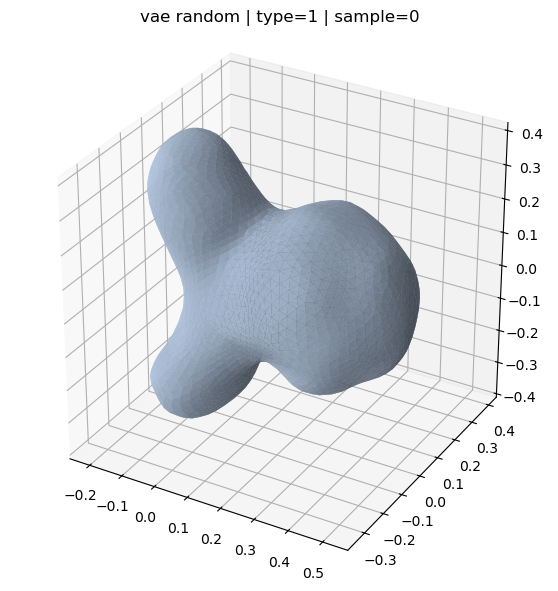

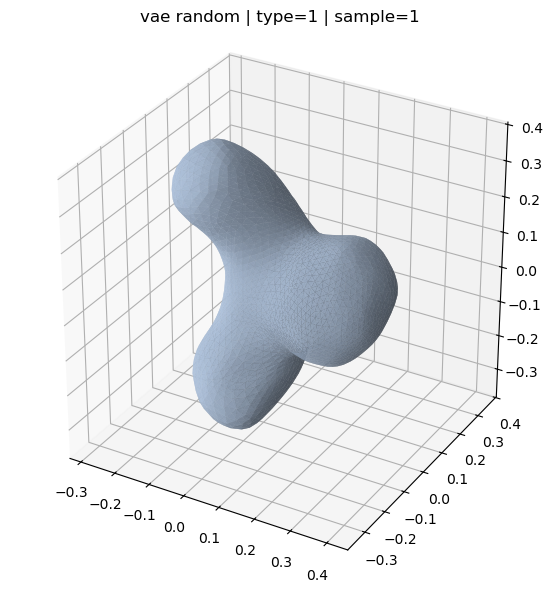

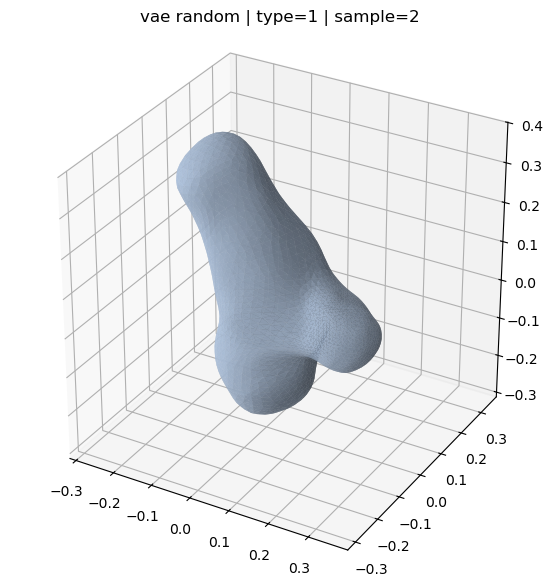

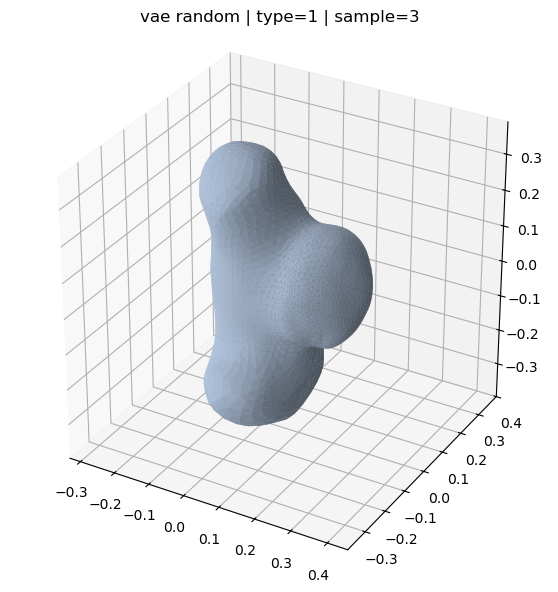

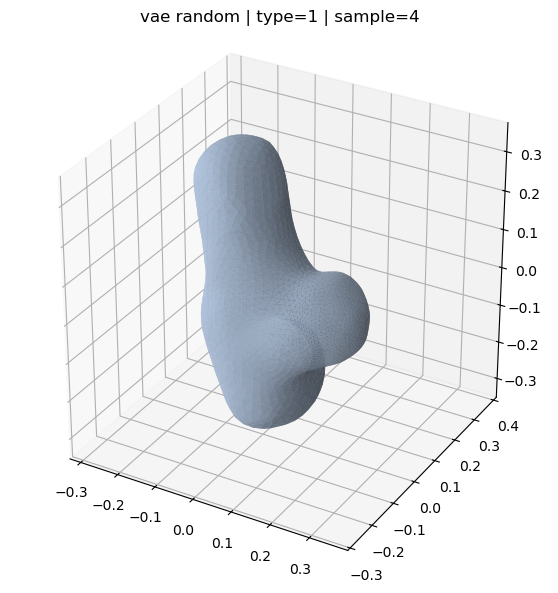

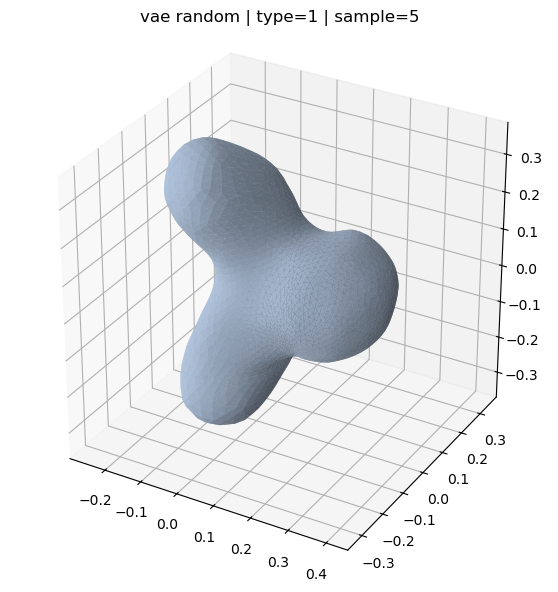

In [6]:
def plot_mesh(mesh, title="generated mesh"):
    verts = mesh.verts_list()[0].detach().cpu().numpy()
    faces = mesh.faces_list()[0].detach().cpu().numpy()
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_trisurf(
        verts[:, 0], verts[:, 1], verts[:, 2], triangles=faces,
        color="lightsteelblue", edgecolor="none", alpha=0.85,
    )
    center = (verts.min(axis=0) + verts.max(axis=0)) / 2
    radius = (verts.max(axis=0) - verts.min(axis=0)).max() / 2
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title(title)
    plt.show()

for i, mesh in enumerate(meshes):
    plot_mesh(mesh, f"{MODEL_KIND} {MODE} | type={int(type_tensor[i])} | sample={i}")

loaded /media/yaplab2/HDD Storage/wenhao/AneuG/checkpoints/v2/ghd_vae/epoch_09000.pth
ghd (4, 432) scale (4, 1) types [1, 1, 1, 1]


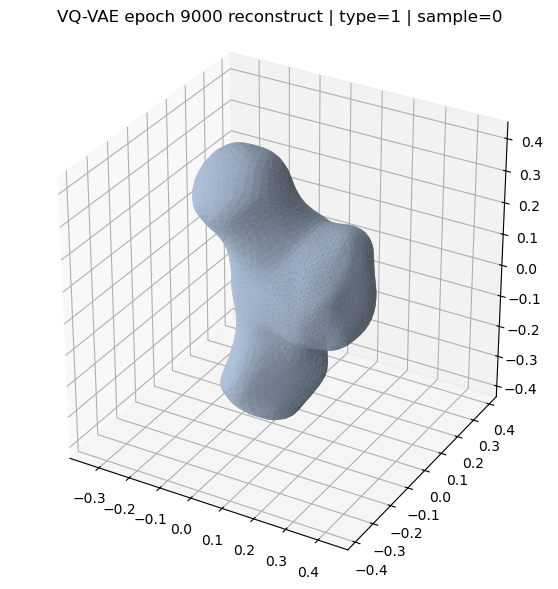

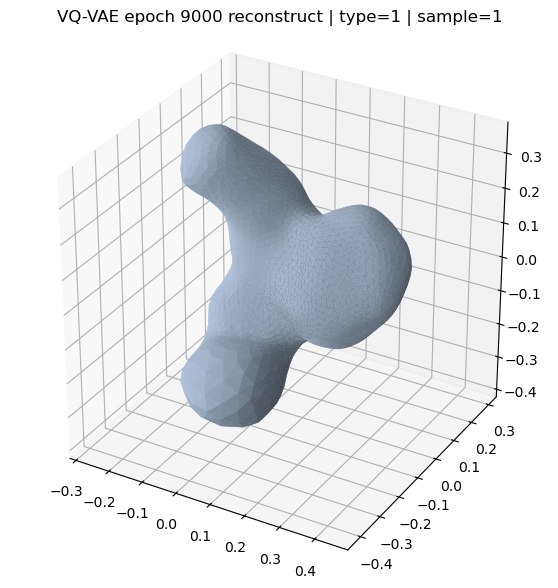

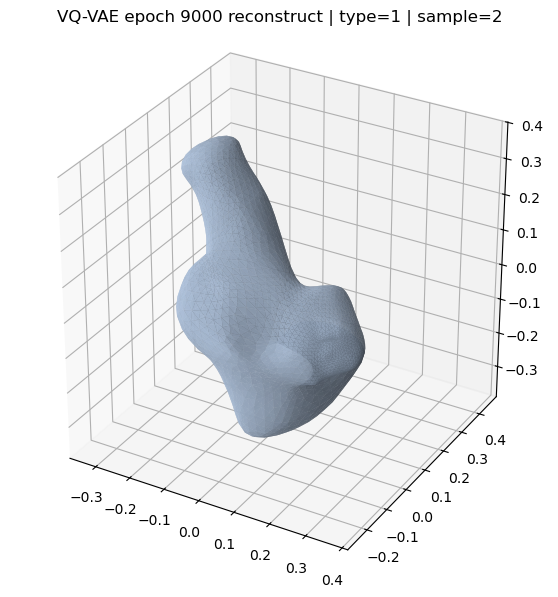

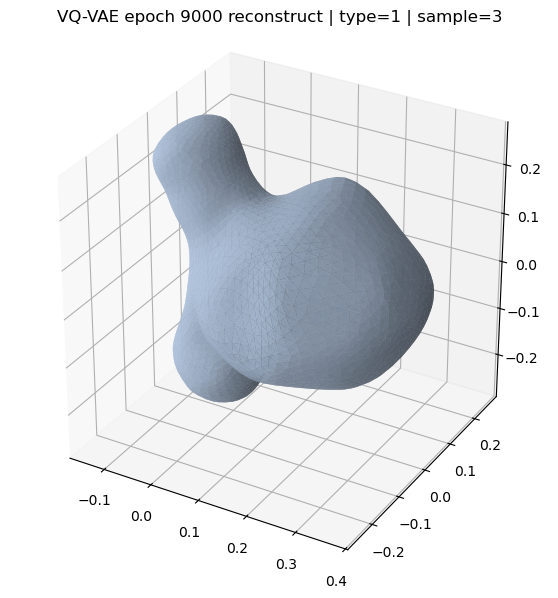

In [7]:
# Quick VQ-VAE checkpoint check: reconstruct processed samples and plot meshes.
VQVAE_EPOCH9000 = ROOT / "checkpoints" / "v2" / "ghd_vae" / "epoch_09000.pth"
VQVAE_CHECK_TYPE = 1
VQVAE_CHECK_SAMPLES = 4

checkpoint = torch.load(VQVAE_EPOCH9000, map_location=DEVICE)
MODEL_KIND = "vae"
MODE = "reconstruct"
ANEURYSM_TYPE = VQVAE_CHECK_TYPE
NUM_SAMPLES = VQVAE_CHECK_SAMPLES

model = build_model(MODEL_KIND, checkpoint)
mean = checkpoint["mean"].to(DEVICE)
std = checkpoint["std"].to(DEVICE)
withscale = bool(checkpoint.get("withscale", True))
ghd_reconstruct = get_ghd_reconstruct(device=DEVICE)

ghd_gen, scale_gen, type_tensor = reconstruct_from_dataset(
    MODEL_KIND, model, ANEURYSM_TYPE, NUM_SAMPLES
)
meshes = [
    mesh_from_ghd(ghd_gen[i:i+1], scale_gen[i:i+1], int(type_tensor[i]))
    for i in range(ghd_gen.shape[0])
]

print(f"loaded {VQVAE_EPOCH9000}")
print("ghd", tuple(ghd_gen.shape), "scale", tuple(scale_gen.shape), "types", type_tensor.tolist())
for i, mesh in enumerate(meshes):
    plot_mesh(mesh, f"VQ-VAE epoch 9000 reconstruct | type={int(type_tensor[i])} | sample={i}")